Loaded fold 0 train partition data:
  upgrade_cohort (train)  : (12537, 81)
  risky_upgrade           : 1,094
  safe_upgrade            : 11,443
  Baseline DR             : 8.73%
  NB03 variables (all univariate results) : 57
  NB04 rules (post group-filter)          : 185
  Financial features                       : 64

LAYER 1 — Single-Variable Warning Factors (fold 0)

FDR-significant variables (q < 0.05), exact-duplicate-free: 44
Layer 1 factors registered : 44
  Risk-reducing (OR < 1)   : 37
  Risk-increasing (OR > 1) : 7
  [Paper reference, full sample: 50 Layer 1 factors]
Saved: ../results/tables/NB06_L1_single_factors_fold0.csv

Layer 1 factor list:
ID       Variable                                OR      q-val Trigger
--------------------------------------------------------------------------------
L1-01    Attr51                               1.335   0.00e+00  HIGH (top 33%)
L1-02    equity_to_assets                     0.740   0.00e+00  LOW (bottom 33%)
L1-03    total_liabili

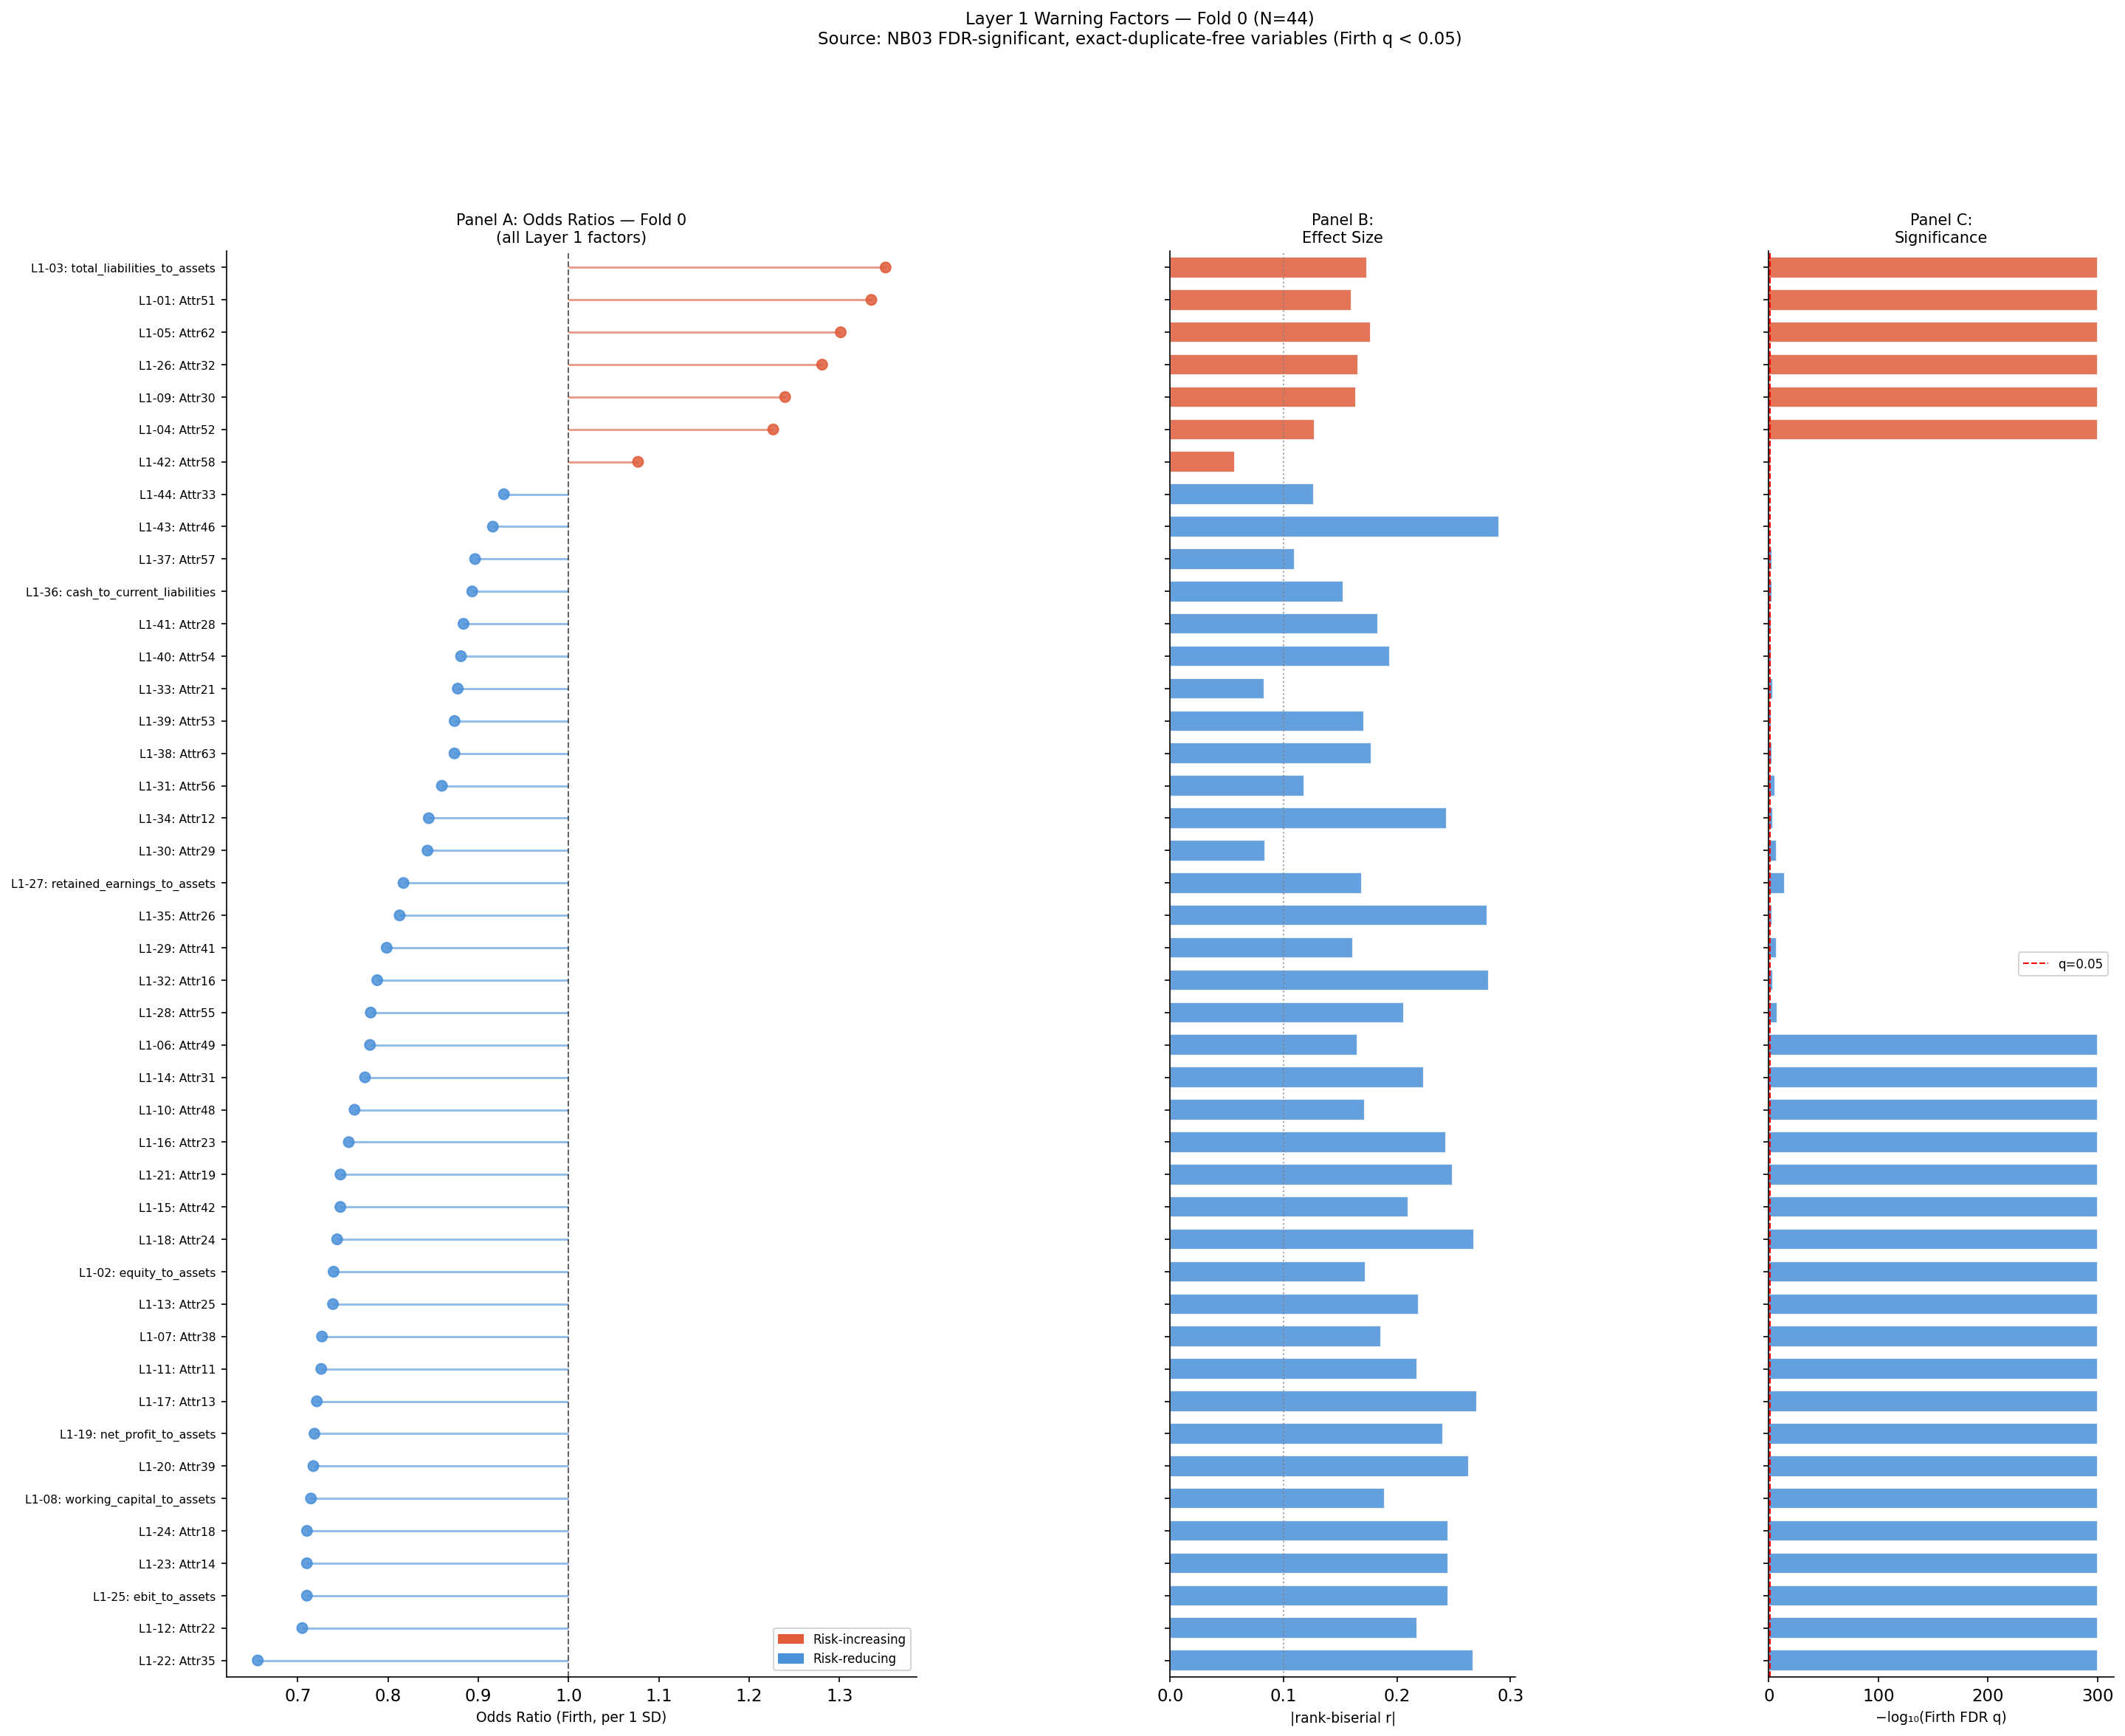

Figure saved: NB06_01_L1_factor_overview_fold0.png

[Figure 2] Layer 2 composite factor overview (fold 0)


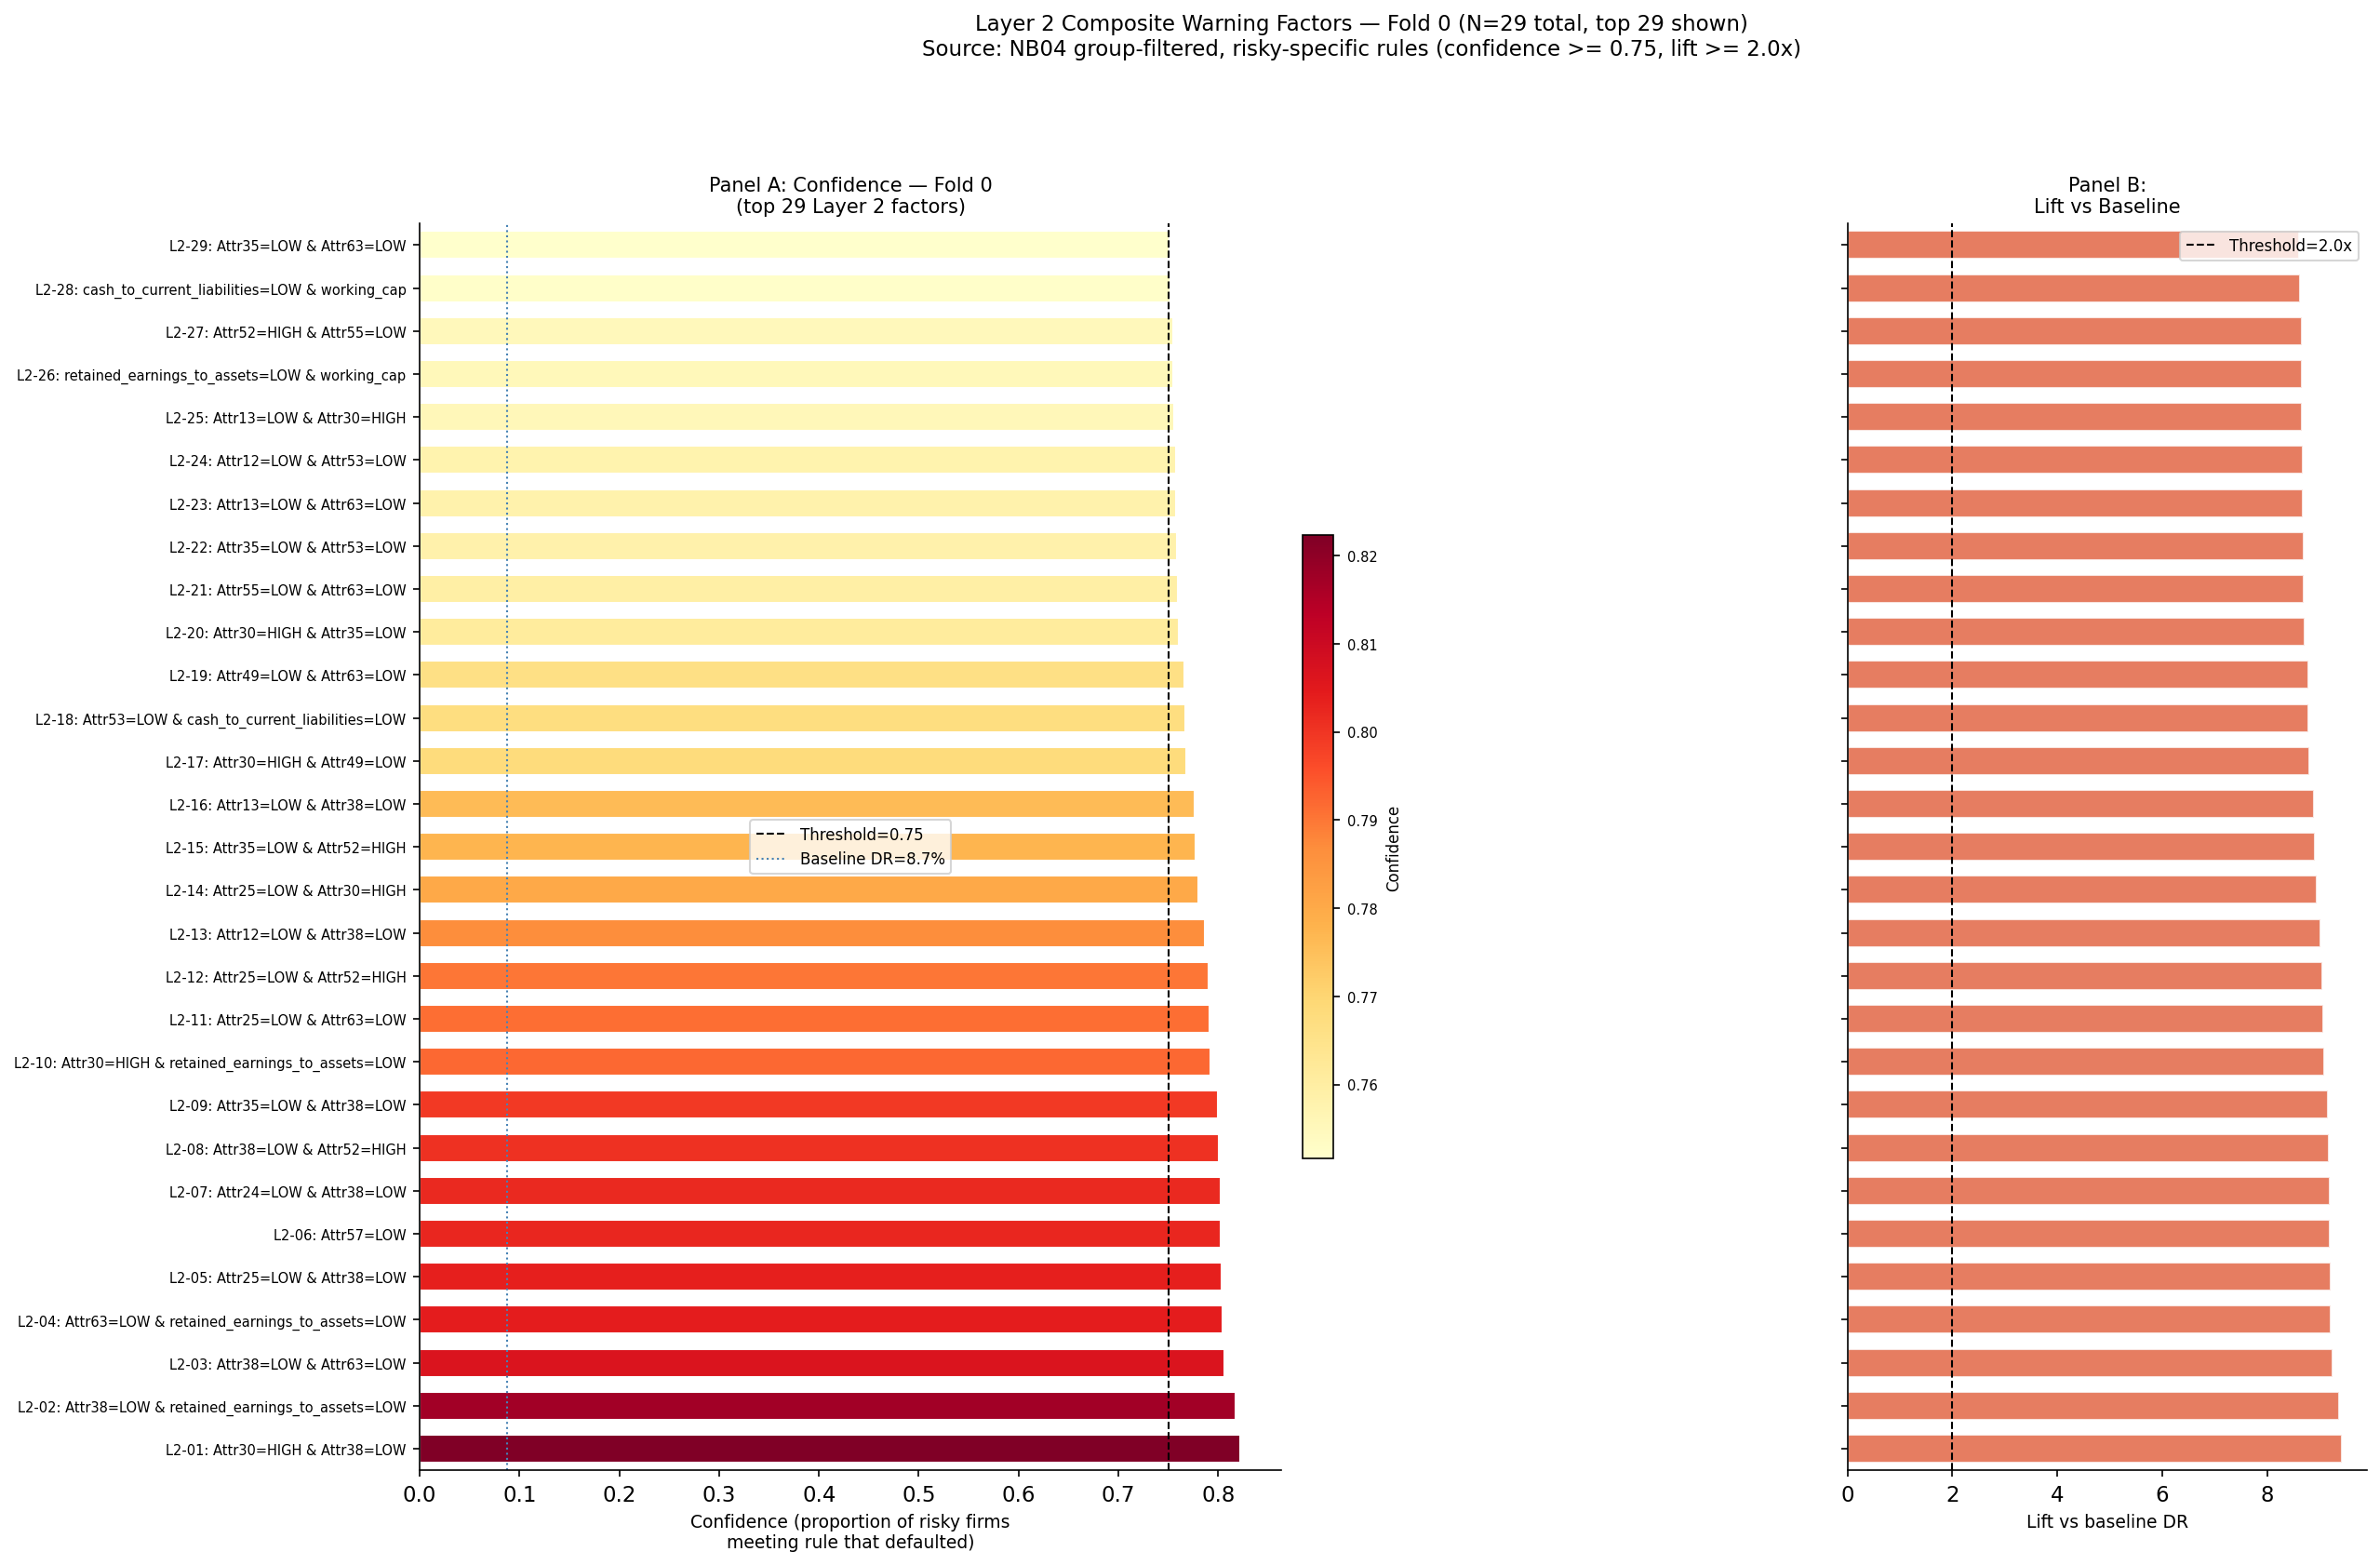

Figure saved: NB06_02_L2_composite_overview_fold0.png

[Step] Saving warning system design specification as CSV (fold 0)...
Saved: ../results/tables/NB06_03_system_design_spec_fold0.csv

NB06 SUMMARY — FOLD 0 TWO-LAYER WARNING FACTOR LIBRARY

Total warning factors : 73
  Layer 1 (single)    : 44
  Layer 2 (composite) : 29
  [Paper reference: 165 total (50 L1 + 115 L2)]

Layer 1: OR range 0.656–1.351, |rb| range 0.057–0.290
Layer 2: Conf range 0.752–0.822, Lift range 8.61x–9.42x

Output files:
  ../results/tables/NB06_L1_single_factors_fold0.csv
  ../results/tables/NB06_L2_composite_factors_fold0.csv
  ../results/tables/NB06_full_factor_library_fold0.csv

Next step -> NB07_simulation.ipynb (retrospective simulation on fold 0's OUTER-HOLDOUT partition — the first time held-out data is used in this fold's pipeline)


In [2]:
# ============================================================================
# NB06_judgment_factors.ipynb  —  Nested CV Version, Step 1: fold 0
#
# Study 2: Synthesising a comprehensive early-warning factor library
#
# ----------------------------------------------------------------------------
# WHAT CHANGED FROM THE ORIGINAL VERSION
# ----------------------------------------------------------------------------
# 1. Input files now point to fold 0's outputs rather than the original
#    single-sample files:
#      NB03_01_univariate_logistic.csv  -> NB03_01_firth_results_fold0.csv
#      NB03b_variable_map.csv           -> NB03b_variable_map_fold0.csv
#      NB04_02_rules_summary.csv        -> NB04_02_rules_summary_fold0.csv
#      NB05_01_cluster_profiles.csv     -> NB05_01_cluster_profiles_fold0.csv
#
# 2. Column names differ because this pipeline's NB03 uses a self-contained
#    Firth implementation (firth_utils.py) rather than the `firthlogist`
#    package the original notebook assumed:
#      sig_firth_fdr  -> sig_fdr
#      OR_firth       -> OR_mle  (this pipeline's OR_mle IS the Firth OR;
#                                  there is no separate uncorrected-MLE
#                                  column carried into the factor library,
#                                  though NB03 Section 1b DID validate this
#                                  Firth OR against a standard MLE OR as a
#                                  sanity check, not as a library column)
#      p_firth_fdr    -> fdr_q
#
# 3. Layer 1 source population: the original notebook filtered on FDR
#    significance alone (50 factors in the paper). This fold's NB03 also
#    removed near-exact duplicate variables (|r|>0.999 — e.g. Attr14/
#    Attr18/ebit_to_assets, which are three names for the same ratio)
#    BEFORE VIF screening. Layer 1 here is built from FDR-significant
#    variables AFTER that exact-duplicate removal (42 variables), since
#    warning an evaluator about the same ratio three times under three
#    different names would not be a meaningful design choice, even for a
#    "breadth over selectivity" Layer 1. This is a deliberate, documented
#    deviation from a literal re-implementation of "all FDR-significant
#    variables."
#
# 4. Layer 2 source: this fold's NB04 already applied a group-redundancy
#    filter (removing near-tautological rules where 2+ items across
#    antecedent+consequent proxy the same latent factor) BEFORE the
#    confidence/lift filtering below. The 185 rules in
#    NB04_02_rules_summary_fold0.csv are therefore already de-duplicated
#    at the "different-signal" level; this notebook's confidence>=0.75
#    filter operates on that already-cleaned set, not on the raw
#    Apriori output.
#
# Input  : data/processed/fold_0/upgrade_cohort_fold0.parquet
#           -> filtered to outer_split == "train"
#          results/tables/NB03_01_firth_results_fold0.csv
#          results/tables/NB03b_variable_map_fold0.csv
#          results/tables/NB04_02_rules_summary_fold0.csv
#          results/tables/NB05_01_cluster_profiles_fold0.csv
# Outputs:
#   results/tables/NB06_L1_single_factors_fold0.csv
#   results/tables/NB06_L2_composite_factors_fold0.csv
#   results/tables/NB06_full_factor_library_fold0.csv
#   results/tables/NB06_03_system_design_spec_fold0.csv
#   results/figures/NB06_01_L1_factor_overview_fold0.png
#   results/figures/NB06_02_L2_composite_overview_fold0.png
# ============================================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi"       : 150,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.size"        : 11,
    "font.family"      : "DejaVu Sans",
})

PROC_DIR  = "../data/processed/"
FIG_DIR   = "../results/figures/"
TABLE_DIR = "../results/tables/"

os.makedirs(FIG_DIR,   exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

RANDOM_SEED = 42
FOLD_ID     = 0   # will become a loop variable in the next version

# ── Layer thresholds ──────────────────────────────────────────────────────────
L1_FDR_THRESHOLD  = 0.05
L2_CONF_THRESHOLD = 0.75
L2_LIFT_THRESHOLD = 2.0


# ── Load fold 0 data ──────────────────────────────────────────────────────────

fold_cohort_path = os.path.join(PROC_DIR, f"fold_{FOLD_ID}", f"upgrade_cohort_fold{FOLD_ID}.parquet")
cohort_full_fold = pd.read_parquet(fold_cohort_path)
cohort = cohort_full_fold[cohort_full_fold["outer_split"] == "train"].copy()

lr_df       = pd.read_csv(os.path.join(TABLE_DIR, f"NB03_01_firth_results_fold{FOLD_ID}.csv"), index_col=0)
var_map     = pd.read_csv(os.path.join(TABLE_DIR, f"NB03b_variable_map_fold{FOLD_ID}.csv"), index_col=0)
rules_df    = pd.read_csv(os.path.join(TABLE_DIR, f"NB04_02_rules_summary_fold{FOLD_ID}.csv"))
profiles_df = pd.read_csv(os.path.join(TABLE_DIR, f"NB05_01_cluster_profiles_fold{FOLD_ID}.csv"), index_col=0)

risky = cohort[cohort["group"] == "risky_upgrade"]
safe  = cohort[cohort["group"] == "safe_upgrade"]

BASELINE_DR = cohort["default"].mean()

EXCLUDE = {
    "default", "year_horizon", "class", "pd_system", "grade_ordinal",
    "grade_diff", "override_flag", "final_grade_ordinal", "system_grade",
    "group", "is_risky", "from_grade", "to_grade", "transition",
    "high_risk_transition", "cluster", "outer_fold", "outer_split",
}
all_fin_cols = [c for c in cohort.columns
                if c not in EXCLUDE
                and cohort[c].dtype in [np.float64, np.int64, float, int]]

print(f"Loaded fold {FOLD_ID} train partition data:")
print(f"  upgrade_cohort (train)  : {cohort.shape}")
print(f"  risky_upgrade           : {len(risky):,}")
print(f"  safe_upgrade            : {len(safe):,}")
print(f"  Baseline DR             : {BASELINE_DR*100:.2f}%")
print(f"  NB03 variables (all univariate results) : {len(lr_df)}")
print(f"  NB04 rules (post group-filter)          : {len(rules_df)}")
print(f"  Financial features                       : {len(all_fin_cols)}")


# ══════════════════════════════════════════════════════════════════════════════
# LAYER 1 — Single-variable warning factors
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print(f"LAYER 1 — Single-Variable Warning Factors (fold {FOLD_ID})")
print("=" * 65)

# Inclusion: Firth FDR q < threshold (column name: sig_fdr, from this
# pipeline's NB03). This lr_df already excludes near-exact-duplicate
# variables (|r|>0.999), since NB03's Section 3b removed those BEFORE
# saving NB03_01_firth_results_fold0.csv — see module docstring above.

L1_candidates = lr_df[lr_df["sig_fdr"] == True].copy()
print(f"\nFDR-significant variables (q < {L1_FDR_THRESHOLD}), "
      f"exact-duplicate-free: {len(L1_candidates)}")

L1_factors = []
factor_id  = 1

for var, row in L1_candidates.iterrows():
    if var not in cohort.columns:
        continue

    vals      = cohort[var].dropna()
    p33       = vals.quantile(0.33)
    p67       = vals.quantile(0.67)
    direction = row["direction"]

    if direction == "risk-reducing":
        trigger_bin  = "LOW"
        trigger_cond = f"<= {p33:.4f}"
        trigger_pct  = "bottom 33%"
        distress_mask = cohort[var] <= p33
    else:
        trigger_bin  = "HIGH"
        trigger_cond = f">= {p67:.4f}"
        trigger_pct  = "top 33%"
        distress_mask = cohort[var] >= p67

    dr_distress = (
        cohort.loc[distress_mask & (cohort["group"] == "risky_upgrade"), "default"].mean()
        if distress_mask.sum() > 0 else np.nan
    )
    dr_non_distress = (
        cohort.loc[~distress_mask & (cohort["group"] == "risky_upgrade"), "default"].mean()
        if (~distress_mask).sum() > 0 else np.nan
    )

    if var in var_map.index and "definition" in var_map.columns:
        definition = var_map.loc[var, "definition"]
    else:
        definition = var

    L1_factors.append({
        "factor_id"        : f"L1-{factor_id:02d}",
        "layer"            : 1,
        "variable"         : var,
        "definition"       : definition,
        "direction"        : direction,
        "OR_mle"           : round(row["OR_mle"], 4),    # this IS the Firth OR in this pipeline
        "rank_biserial"    : round(row["rank_biserial"], 4),
        "firth_fdr_q"      : row["fdr_q"],
        "trigger_bin"      : trigger_bin,
        "trigger_condition": trigger_cond,
        "trigger_pct"      : trigger_pct,
        "threshold_p33"    : round(p33, 4),
        "threshold_p67"    : round(p67, 4),
        "risky_median"     : round(risky[var].median(), 4) if var in risky.columns else np.nan,
        "safe_median"      : round(safe[var].median(),  4) if var in safe.columns else np.nan,
    })
    factor_id += 1

L1_df = pd.DataFrame(L1_factors).set_index("factor_id")

out_path = os.path.join(TABLE_DIR, f"NB06_L1_single_factors_fold{FOLD_ID}.csv")
L1_df.to_csv(out_path)
print(f"Layer 1 factors registered : {len(L1_df)}")
print(f"  Risk-reducing (OR < 1)   : {(L1_df['direction']=='risk-reducing').sum()}")
print(f"  Risk-increasing (OR > 1) : {(L1_df['direction']=='risk-increasing').sum()}")
print(f"  [Paper reference, full sample: 50 Layer 1 factors]")
print(f"Saved: {out_path}")

print(f"\nLayer 1 factor list:")
print(f"{'ID':<8} {'Variable':<35} {'OR':>6} {'q-val':>10} {'Trigger'}")
print("-" * 80)
for fid, row in L1_df.iterrows():
    q_str = f"{row['firth_fdr_q']:.2e}" if row['firth_fdr_q'] < 0.001 else f"{row['firth_fdr_q']:.4f}"
    print(f"{fid:<8} {row['variable']:<35} {row['OR_mle']:>6.3f} {q_str:>10}  "
          f"{row['trigger_bin']} ({row['trigger_pct']})")


# ══════════════════════════════════════════════════════════════════════════════
# LAYER 2 — Composite warning factors (association rules)
# [REVISED] Each rule's per-condition tertile thresholds (p33/p67) are now
# saved as explicit columns (cond1_var, cond1_bin, cond1_p33, cond1_p67,
# cond2_..., cond3_...), rather than only embedded as text inside
# conditions_detail. This is required so that NB07 can apply these EXACT
# TRAIN-DERIVED thresholds to the outer-holdout partition without
# recomputing tertiles from holdout data (which would leak holdout
# information into the factor definitions being validated).
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print(f"LAYER 2 — Composite Warning Factors (fold {FOLD_ID})")
print("=" * 65)

L2_rules = rules_df[
    (rules_df["confidence"]      >= L2_CONF_THRESHOLD) &
    (rules_df["lift_vs_baseline"] >= L2_LIFT_THRESHOLD)
].copy()

L2_rules = (L2_rules
            .sort_values("confidence", ascending=False)
            .drop_duplicates(subset=["antecedents_str"])
            .reset_index(drop=True))

print(f"\nRules meeting threshold (conf>={L2_CONF_THRESHOLD}, lift>={L2_LIFT_THRESHOLD}x), "
      f"from fold {FOLD_ID}'s {len(rules_df)} group-filtered candidates: {len(L2_rules)}")

MAX_CONDITIONS = 3   # matches MAX_ANTECEDENT_LEN from NB04

L2_factors = []
for i, row in L2_rules.iterrows():
    items      = row["antecedents_str"].split(" & ")
    conditions = []

    # [NEW] per-condition threshold storage, initialised to NaN/None
    cond_data = {}
    for c in range(1, MAX_CONDITIONS + 1):
        cond_data[f"cond{c}_var"] = None
        cond_data[f"cond{c}_bin"] = None
        cond_data[f"cond{c}_p33"] = np.nan
        cond_data[f"cond{c}_p67"] = np.nan

    for c_idx, item in enumerate(items, start=1):
        parts = item.split("=")
        if len(parts) == 2:
            var_name, bin_val = parts[0].strip(), parts[1].strip()
            vals = cohort[var_name].dropna() if var_name in cohort.columns else pd.Series()
            if len(vals) > 0:
                p33 = vals.quantile(0.33)
                p67 = vals.quantile(0.67)
                if bin_val == "LOW":
                    cond = f"{var_name} <= {p33:.4f}"
                elif bin_val == "HIGH":
                    cond = f"{var_name} >= {p67:.4f}"
                else:
                    cond = f"{var_name} = {bin_val}"

                # [NEW] store this condition's threshold explicitly
                if c_idx <= MAX_CONDITIONS:
                    cond_data[f"cond{c_idx}_var"] = var_name
                    cond_data[f"cond{c_idx}_bin"] = bin_val
                    cond_data[f"cond{c_idx}_p33"] = round(p33, 6)
                    cond_data[f"cond{c_idx}_p67"] = round(p67, 6)
            else:
                cond = item
            conditions.append(cond)

    factor_record = {
        "factor_id"          : f"L2-{i+1:02d}",
        "layer"              : 2,
        "antecedents_str"    : row["antecedents_str"],
        "consequents_str"    : row["consequents_str"],
        "n_conditions"       : len(items),
        "conditions_detail"  : " AND ".join(conditions),
        "support"            : round(row["support"], 4),
        "confidence"         : round(row["confidence"], 4),
        "lift_vs_baseline"   : round(row["lift_vs_baseline"], 4),
        "conf_safe"          : round(row["conf_safe"], 4),
        "conf_diff"          : round(row["conf_diff"], 4),
        "trigger_description": (
            f"Firm simultaneously satisfies: {row['antecedents_str']}. "
            f"Among upgrade-overridden firms meeting this condition, "
            f"confidence={row['confidence']:.1%} "
            f"(vs {row['conf_safe']:.1%} in safe group). "
            f"Lift vs baseline = {row['lift_vs_baseline']:.1f}x."
        ),
    }
    factor_record.update(cond_data)   # [NEW] merge in the explicit threshold columns
    L2_factors.append(factor_record)

L2_df = pd.DataFrame(L2_factors).set_index("factor_id")

out_path = os.path.join(TABLE_DIR, f"NB06_L2_composite_factors_fold{FOLD_ID}.csv")
L2_df.to_csv(out_path)
print(f"Layer 2 factors registered : {len(L2_df)}")
print(f"  1-condition rules        : {(L2_df['n_conditions']==1).sum()}")
print(f"  2-condition rules        : {(L2_df['n_conditions']==2).sum()}")
print(f"  3-condition rules        : {(L2_df['n_conditions']==3).sum()}")
print(f"  [Paper reference, full sample: 115 Layer 2 factors]")
print(f"  [NEW] Per-condition thresholds saved as cond1_var/cond1_p33/... "
      f"columns for downstream out-of-fold application (NB07).")
print(f"Saved: {out_path}")

print(f"\nTop 20 Layer 2 factors:")
print(f"{'ID':<8} {'Antecedents':<50} {'Conf':>6} {'Lift':>6} {'CDiff':>6}")
print("-" * 80)
for fid, row in L2_df.head(20).iterrows():
    ant_short = row["antecedents_str"][:48]
    print(f"{fid:<8} {ant_short:<50} {row['confidence']:>6.3f} "
          f"{row['lift_vs_baseline']:>6.2f} {row['conf_diff']:>6.3f}")


# ══════════════════════════════════════════════════════════════════════════════
# Full factor library
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print(f"FULL FACTOR LIBRARY SUMMARY — FOLD {FOLD_ID}")
print("=" * 65)

L1_export = L1_df[["layer", "variable", "definition", "direction",
                    "OR_mle", "rank_biserial", "firth_fdr_q",
                    "trigger_condition", "trigger_pct"]].copy()
L1_export["antecedents_str"]  = L1_export["variable"]
L1_export["confidence"]       = np.nan
L1_export["lift_vs_baseline"] = np.nan

L2_export = L2_df[["layer", "antecedents_str", "conditions_detail",
                    "confidence", "lift_vs_baseline", "conf_diff"]].copy()

full_library = pd.concat([L1_export, L2_export], axis=0, ignore_index=True)
full_library.index = (
    [f"L1-{i+1:02d}" for i in range(len(L1_export))] +
    [f"L2-{i+1:02d}" for i in range(len(L2_export))]
)

out_path = os.path.join(TABLE_DIR, f"NB06_full_factor_library_fold{FOLD_ID}.csv")
full_library.to_csv(out_path)

print(f"\nTotal warning factors in library : {len(full_library)}")
print(f"  Layer 1 (single variable)      : {len(L1_df)}")
print(f"  Layer 2 (composite pattern)    : {len(L2_df)}")
print(f"  [Paper reference, full sample: 165 total (50 L1 + 115 L2)]")
print(f"Saved: {out_path}")


# ── Figure 1: Layer 1 overview ────────────────────────────────────────────────

print(f"\n[Figure 1] Layer 1 factor overview (fold {FOLD_ID})")

L1_sorted = L1_df.sort_values("OR_mle", ascending=True)
n_l1      = len(L1_sorted)

fig, axes = plt.subplots(1, 3, figsize=(22, max(8, n_l1 * 0.38)),
                         gridspec_kw={"width_ratios": [3, 1.5, 1.5],
                                      "wspace": 0.55})
ax_or, ax_rb, ax_q = axes

y_pos  = np.arange(n_l1)
colors = L1_sorted["direction"].map(
    {"risk-increasing": "#E05C3A", "risk-reducing": "#4A90D9"}
).values

ax_or.hlines(y_pos, L1_sorted["OR_mle"].values, 1.0,
             color=colors, linewidth=1.4, alpha=0.6)
ax_or.scatter(L1_sorted["OR_mle"], y_pos,
              c=colors, s=45, zorder=5, alpha=0.85)
ax_or.axvline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.6)
ax_or.set_yticks(y_pos)
ax_or.set_yticklabels(
    [f"{fid}: {row['variable']}" for fid, row in L1_sorted.iterrows()],
    fontsize=7.5,
)
ax_or.set_ylim(-0.5, n_l1 - 0.5)
ax_or.set_xlabel("Odds Ratio (Firth, per 1 SD)", fontsize=9)
ax_or.set_title(f"Panel A: Odds Ratios — Fold {FOLD_ID}\n(all Layer 1 factors)", fontsize=10)
red_p  = mpatches.Patch(color="#E05C3A", label="Risk-increasing")
blue_p = mpatches.Patch(color="#4A90D9", label="Risk-reducing")
ax_or.legend(handles=[red_p, blue_p], fontsize=8, loc="lower right")

ax_rb.barh(y_pos, L1_sorted["rank_biserial"].abs(),
           color=colors, edgecolor="white", height=0.65, alpha=0.85)
ax_rb.set_yticks(y_pos)
ax_rb.set_yticklabels([])
ax_rb.set_ylim(-0.5, n_l1 - 0.5)
ax_rb.set_xlabel("|rank-biserial r|", fontsize=9)
ax_rb.set_title("Panel B:\nEffect Size", fontsize=10)
ax_rb.axvline(0.10, color="grey", linestyle=":", linewidth=1, alpha=0.7)

L1_sorted["neg_log_q"] = -np.log10(L1_sorted["firth_fdr_q"].clip(lower=1e-300))
ax_q.barh(y_pos, L1_sorted["neg_log_q"],
          color=colors, edgecolor="white", height=0.65, alpha=0.85)
ax_q.set_yticks(y_pos)
ax_q.set_yticklabels([])
ax_q.set_ylim(-0.5, n_l1 - 0.5)
ax_q.set_xlabel("−log₁₀(Firth FDR q)", fontsize=9)
ax_q.set_title("Panel C:\nSignificance", fontsize=10)
ax_q.axvline(-np.log10(0.05), color="red", linestyle="--",
             linewidth=1, label="q=0.05")
ax_q.legend(fontsize=8)

plt.suptitle(
    f"Layer 1 Warning Factors — Fold {FOLD_ID} (N={n_l1})\n"
    f"Source: NB03 FDR-significant, exact-duplicate-free variables (Firth q < {L1_FDR_THRESHOLD})",
    fontsize=11, y=1.01,
)
plt.savefig(FIG_DIR + f"NB06_01_L1_factor_overview_fold{FOLD_ID}.png", bbox_inches="tight")
plt.show()
print(f"Figure saved: NB06_01_L1_factor_overview_fold{FOLD_ID}.png")


# ── Figure 2: Layer 2 overview ────────────────────────────────────────────────

print(f"\n[Figure 2] Layer 2 composite factor overview (fold {FOLD_ID})")

if len(L2_df) > 0:
    top_l2 = L2_df.head(30)
    n_l2   = len(top_l2)

    fig, axes = plt.subplots(1, 2, figsize=(18, max(7, n_l2 * 0.40)),
                             gridspec_kw={"width_ratios": [3, 1.5], "wspace": 0.50})
    ax_conf, ax_lift = axes

    y2     = np.arange(n_l2)
    labels = [
        f"{fid}: " + row["antecedents_str"][:45]
        for fid, row in top_l2.iterrows()
    ]

    norm_conf = plt.Normalize(top_l2["confidence"].min(), top_l2["confidence"].max())
    bar_colors = plt.cm.YlOrRd(norm_conf(top_l2["confidence"].values))

    ax_conf.barh(y2, top_l2["confidence"], color=bar_colors,
                 edgecolor="white", height=0.65)
    ax_conf.axvline(L2_CONF_THRESHOLD, color="black", linestyle="--",
                    linewidth=1, label=f"Threshold={L2_CONF_THRESHOLD}")
    ax_conf.axvline(BASELINE_DR, color="steelblue", linestyle=":",
                    linewidth=1, label=f"Baseline DR={BASELINE_DR*100:.1f}%")
    ax_conf.set_yticks(y2)
    ax_conf.set_yticklabels(labels, fontsize=7)
    ax_conf.set_ylim(-0.5, n_l2 - 0.5)
    ax_conf.set_xlabel("Confidence (proportion of risky firms\nmeeting rule that defaulted)",
                       fontsize=9)
    ax_conf.set_title(f"Panel A: Confidence — Fold {FOLD_ID}\n(top {n_l2} Layer 2 factors)", fontsize=10)
    ax_conf.legend(fontsize=8)

    sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=norm_conf)
    sm.set_array([])
    cb = plt.colorbar(sm, ax=ax_conf, shrink=0.5, pad=0.02)
    cb.set_label("Confidence", fontsize=8)
    cb.ax.tick_params(labelsize=7)

    ax_lift.barh(y2, top_l2["lift_vs_baseline"],
                 color="#E05C3A", alpha=0.80, edgecolor="white", height=0.65)
    ax_lift.axvline(L2_LIFT_THRESHOLD, color="black", linestyle="--",
                    linewidth=1, label=f"Threshold={L2_LIFT_THRESHOLD}x")
    ax_lift.set_yticks(y2)
    ax_lift.set_yticklabels([])
    ax_lift.set_ylim(-0.5, n_l2 - 0.5)
    ax_lift.set_xlabel("Lift vs baseline DR", fontsize=9)
    ax_lift.set_title("Panel B:\nLift vs Baseline", fontsize=10)
    ax_lift.legend(fontsize=8)

    plt.suptitle(
        f"Layer 2 Composite Warning Factors — Fold {FOLD_ID} "
        f"(N={len(L2_df)} total, top {n_l2} shown)\n"
        f"Source: NB04 group-filtered, risky-specific rules "
        f"(confidence >= {L2_CONF_THRESHOLD}, lift >= {L2_LIFT_THRESHOLD}x)",
        fontsize=11, y=1.01,
    )
    plt.savefig(FIG_DIR + f"NB06_02_L2_composite_overview_fold{FOLD_ID}.png", bbox_inches="tight")
    plt.show()
    print(f"Figure saved: NB06_02_L2_composite_overview_fold{FOLD_ID}.png")
else:
    print("  [WARNING] No Layer 2 factors to plot.")


# ── System design spec — CSV ───────────────────────────────────────────────────

print(f"\n[Step] Saving warning system design specification as CSV (fold {FOLD_ID})...")

design_rows = []

flow_steps = [
    {"step": 1, "component": "Input",
     "description": "Evaluator proposes an upgrade override (grade increase)",
     "trigger": "Evaluator action",
     "output": "Override request with firm ID and proposed grade"},
    {"step": 2, "component": "Data retrieval",
     "description": "System retrieves firm's latest financial data from database",
     "trigger": "Automatic on override input",
     "output": "Financial feature vector"},
    {"step": 3, "component": "Layer 1 check",
     "description": (
         f"System checks all {len(L1_df)} single-variable warning factors "
         f"(fold {FOLD_ID} training-partition estimate). "
         f"For each factor, firm value is compared to the distress tertile threshold. "
         f"Source: NB03 Firth logistic regression (FDR q < {L1_FDR_THRESHOLD}). "
         f"OR range: {L1_df['OR_mle'].min():.3f}–{L1_df['OR_mle'].max():.3f}."
     ),
     "trigger": "Firm value <= p33 (risk-reducing) or >= p67 (risk-increasing)",
     "output": f"List of triggered L1 factors (0 to {len(L1_df)} possible)"},
    {"step": 4, "component": "Layer 2 check",
     "description": (
         f"System checks all {len(L2_df)} composite-pattern warning factors "
         f"(fold {FOLD_ID} training-partition estimate). "
         f"Source: NB04 group-filtered, risky-specific association rules "
         f"(confidence >= {L2_CONF_THRESHOLD}, lift >= {L2_LIFT_THRESHOLD}x)."
     ),
     "trigger": "Firm simultaneously satisfies all antecedent bin conditions",
     "output": f"List of triggered L2 rules (0 to {len(L2_df)} possible)"},
    {"step": 5, "component": "Warning display",
     "description": "If any L1 or L2 factor is triggered, system displays warning to evaluator.",
     "trigger": "One or more factors triggered in L1 or L2",
     "output": "Warning panel shown to evaluator before override is finalised"},
    {"step": 6, "component": "No warning",
     "description": "No factors triggered. Override proceeds without system intervention.",
     "trigger": "Zero factors triggered in both L1 and L2",
     "output": "Override finalised normally"},
    {"step": 7, "component": "Evaluator decision",
     "description": "Evaluator reviews triggered warnings; warning is advisory only.",
     "trigger": "Evaluator action after reviewing warnings",
     "output": "Final grade recorded; warning response logged"},
]
for row in flow_steps:
    row["category"] = "Process flow"
    design_rows.append(row)

l1_params = [
    {"step": "L1-P1", "component": "Layer 1 — factor source",
     "description": f"NB03 univariate Firth logistic regression on fold {FOLD_ID} training partition",
     "trigger": "—", "output": "—", "category": "L1 design"},
    {"step": "L1-P2", "component": "Layer 1 — inclusion criterion",
     "description": f"Firth FDR q < {L1_FDR_THRESHOLD} (Benjamini-Hochberg), after exact-duplicate removal",
     "trigger": "—", "output": "—", "category": "L1 design"},
    {"step": "L1-P3", "component": "Layer 1 — factor count",
     "description": f"N = {len(L1_df)} factors ({(L1_df['direction']=='risk-reducing').sum()} risk-reducing, "
                    f"{(L1_df['direction']=='risk-increasing').sum()} risk-increasing)",
     "trigger": "—", "output": "—", "category": "L1 design"},
    {"step": "L1-P4", "component": "Layer 1 — trigger threshold",
     "description": f"Distress tertile computed on fold {FOLD_ID} training partition.",
     "trigger": "—", "output": "—", "category": "L1 design"},
]
design_rows.extend(l1_params)

l2_params = [
    {"step": "L2-P1", "component": "Layer 2 — factor source",
     "description": f"NB04 group-filtered, risky-specific association rules, fold {FOLD_ID} training partition",
     "trigger": "—", "output": "—", "category": "L2 design"},
    {"step": "L2-P2", "component": "Layer 2 — inclusion criteria",
     "description": f"confidence >= {L2_CONF_THRESHOLD} AND lift_vs_baseline >= {L2_LIFT_THRESHOLD}x, "
                    f"applied to rules already surviving NB04's group-redundancy filter",
     "trigger": "—", "output": "—", "category": "L2 design"},
    {"step": "L2-P3", "component": "Layer 2 — factor count",
     "description": f"N = {len(L2_df)} composite rules",
     "trigger": "—", "output": "—", "category": "L2 design"},
]
design_rows.extend(l2_params)

sys_params = [
    {"step": "SYS-1", "component": "Warning mode",
     "description": "Advisory (non-blocking).",
     "trigger": "—", "output": "—", "category": "System parameters"},
    {"step": "SYS-4", "component": "Total factors",
     "description": f"L1: {len(L1_df)} + L2: {len(L2_df)} = {len(L1_df)+len(L2_df)} total, fold {FOLD_ID}.",
     "trigger": "—", "output": "—", "category": "System parameters"},
    {"step": "SYS-5", "component": "Baseline default rate",
     "description": f"Fold {FOLD_ID} training partition: {BASELINE_DR*100:.2f}% (N={len(cohort):,}).",
     "trigger": "—", "output": "—", "category": "System parameters"},
]
design_rows.extend(sys_params)

design_df = pd.DataFrame(design_rows)[
    ["category", "step", "component", "description", "trigger", "output"]
]
out_path = os.path.join(TABLE_DIR, f"NB06_03_system_design_spec_fold{FOLD_ID}.csv")
design_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")


# ── Final summary ─────────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print(f"NB06 SUMMARY — FOLD {FOLD_ID} TWO-LAYER WARNING FACTOR LIBRARY")
print("=" * 65)
print(f"\nTotal warning factors : {len(full_library)}")
print(f"  Layer 1 (single)    : {len(L1_df)}")
print(f"  Layer 2 (composite) : {len(L2_df)}")
print(f"  [Paper reference: 165 total (50 L1 + 115 L2)]")
print()
print(f"Layer 1: OR range {L1_df['OR_mle'].min():.3f}–{L1_df['OR_mle'].max():.3f}, "
      f"|rb| range {L1_df['rank_biserial'].abs().min():.3f}–{L1_df['rank_biserial'].abs().max():.3f}")
if len(L2_df) > 0:
    print(f"Layer 2: Conf range {L2_df['confidence'].min():.3f}–{L2_df['confidence'].max():.3f}, "
          f"Lift range {L2_df['lift_vs_baseline'].min():.2f}x–{L2_df['lift_vs_baseline'].max():.2f}x")
print()
print("Output files:")
print(f"  {TABLE_DIR}NB06_L1_single_factors_fold{FOLD_ID}.csv")
print(f"  {TABLE_DIR}NB06_L2_composite_factors_fold{FOLD_ID}.csv")
print(f"  {TABLE_DIR}NB06_full_factor_library_fold{FOLD_ID}.csv")
print()
print(f"Next step -> NB07_simulation.ipynb (retrospective simulation on "
      f"fold {FOLD_ID}'s OUTER-HOLDOUT partition — the first time held-out "
      f"data is used in this fold's pipeline)")

In [3]:
# ── 검증: L2_df에 cond1_var 등 컬럼이 제대로 저장되었는지 확인 ──────────────

check_cols = [
    "antecedents_str", "n_conditions",
    "cond1_var", "cond1_bin", "cond1_p33", "cond1_p67",
    "cond2_var", "cond2_bin", "cond2_p33", "cond2_p67",
]

print("L2_df 컬럼 목록:")
print(L2_df.columns.tolist())

print("\n상위 5개 factor의 조건 상세 확인:")
print(L2_df[check_cols].head(5).to_string())

L2_df 컬럼 목록:
['layer', 'antecedents_str', 'consequents_str', 'n_conditions', 'conditions_detail', 'support', 'confidence', 'lift_vs_baseline', 'conf_safe', 'conf_diff', 'trigger_description', 'cond1_var', 'cond1_bin', 'cond1_p33', 'cond1_p67', 'cond2_var', 'cond2_bin', 'cond2_p33', 'cond2_p67', 'cond3_var', 'cond3_bin', 'cond3_p33', 'cond3_p67']

상위 5개 factor의 조건 상세 확인:
                                        antecedents_str  n_conditions cond1_var cond1_bin  cond1_p33  cond1_p67                    cond2_var cond2_bin  cond2_p33  cond2_p67
factor_id                                                                                                                                                                   
L2-01                          Attr30=HIGH & Attr38=LOW             2    Attr30      HIGH   0.189020   0.417941                       Attr38       LOW   0.342717   0.579132
L2-02      Attr38=LOW & retained_earnings_to_assets=LOW             2    Attr38       LOW   0.342717   0.579